In [3]:
%load_ext autoreload
%autoreload 2

from algo_align_research_utils.paths import get_project_root_str

project_root = get_project_root_str()
project_root


'c:/Users/omers/CodeProjects/learning-tsp'

In [ ]:
from tqdm import tqdm
import os
from os import path

# filename = path.join(project_root, "data/tsp/tsp10-200_concorde.txt")
# filename = path.join(project_root, "data/tsp/tsp10-200_omer_test_2.txt")
# filename = path.join(project_root, "data/tsp/tsp10-200_cnocorde_with_a_100.2.txt")
# filename = path.join(project_root, "data/tsp/tsp10-200_square_side_200_concorde_20250811_152944.txt")
# filename = path.join(project_root, "data/tsp/tsp10-200_concorde_with_side_100_solved_2.txt")
filename = path.join(project_root, "data/tsp/tsp10-200_square_side_400_concorde_20250812_011124.txt")


# Get the total number of lines in the file without iteration
with open(filename, "r") as file:
    total_lines = sum(1 for _ in file)

print(f"Total lines in the file: {total_lines}")


Total lines in the file: 25600


In [6]:


from algo_align_research_utils.datasets_analysis import dataset_control_parameter_analysis


df_with_control_parameter = dataset_control_parameter_analysis(
    filename=filename,
    square_size=400 ** 2,
)
df_with_control_parameter

Total lines: 25600


100%|██████████| 25600/25600 [00:02<00:00, 8687.15it/s] 


,num_nodes,tour_length,control_parameter
0,10,1141.964783,0.902802
1,10,1295.728484,1.024363
2,10,1404.838923,1.110623
3,10,1264.089942,0.999351
4,10,1277.667171,1.010085
...,...,...,...
25595,200,4496.659855,0.794905
25596,200,4589.707937,0.811353
25597,200,4543.512415,0.803187
25598,200,4669.242500,0.825413


C:\Users\omers\AppData\Local\Temp\ipykernel_9612\3119761343.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Control Parameter Range', order=labels, palette='viridis')


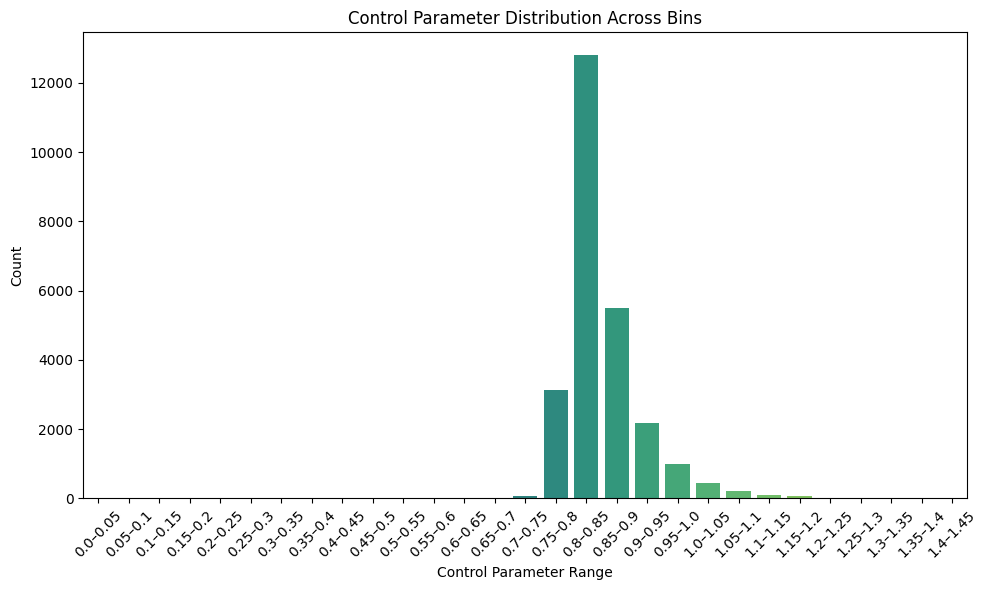

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

control_parameters  = df_with_control_parameter['control_parameter'].values
# probabilities = np.random.rand(1280)  # Random probabilities between 0 and 1


# Create bins and labels
# bins = np.arange(0.7, 1.0, 0.01)
bins = np.arange(0.0, 1.5, 0.05)
labels = [f'{round(bins[i], 2)}–{round(bins[i+1], 2)}' for i in range(len(bins)-1)]

# Bin the data
binned_control_parameters = pd.cut(control_parameters, bins=bins, labels=labels, include_lowest=True)

# Create a DataFrame for plotting
df = pd.DataFrame({'Control Parameter Range': binned_control_parameters})

# Plot using seabornon
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Control Parameter Range', order=labels, palette='viridis')
plt.title('Control Parameter Distribution Across Bins')
plt.xlabel('Control Parameter Range')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# df.value_counts()